![NVIDIA Logo](images/nvidia.png)

# Non-linear Passthrough Pipeline

In this notebook we'll begin our exploration of non-linear pipelines by creating a simple passthrough pipeline that utilizes Morpheus's non-linear `Pipeline` constructor.

---

## Objectives

By the time you complete this notebook you will be able to:

- Create simple non-linear pipelines.
- Connect stages in non-linear pipelines with edges.

---

## Imports

In [1]:
import logging

from IPython.display import Image

from morpheus.pipeline import Pipeline

from morpheus.config import Config

from morpheus.stages.input.file_source_stage import FileSourceStage
from morpheus.stages.output.in_memory_sink_stage import InMemorySinkStage

from morpheus.utils.logger import configure_logging, reset_logging

---

## Load Data

In [2]:
input_file = 'data/simple_user_log.jsonlines'

---

## Create Non-linear Pipeline

Up until this point in time in the workshop, we have created all pipelines using the `LinearPipeline` constructor, which, as the name suggests, is used for creating linear pipelines, i.e., pipelines which consist only of stages that have single inputs, single outputs, and where data always flows linearly through the stages of the constructed pipeline.

Presently we are going to create a new pipeline using `Pipeline`, which will open up the possibility of creating pipelines containing stages with multiple inputs and/or outputs, and, directing data in non-linear, branching, and even circular paths through our pipelines.

In [3]:
config = Config()

In [4]:
pipeline = Pipeline(config)

Just like with linear pipelines, (non-linear) pipelines need to begin with a source stage. When we worked with linear pipelines we used our pipeline object's `set_source` method.

When working with the `Pipeline` constructor we do not use the `set_source` method, even for the source stage of our pipeline and instead define our source stage using the familiar `add_stage` method.

Additionally, and you will see why in a moment, whenever we create stages for a non-linear pipeline we should always take care to assign the stage to a variable for use later in our code.

Thus, to define a source stage we do:

In [5]:
source = pipeline.add_stage(FileSourceStage(config, filename=input_file, iterative=False))

To finish adding stages to our current pipeline, since we are looking to keep it very simple, we will add an `InMemorySinkStage`, assigning it to a variable `in_mem_sink` as we have done many times before.

In [6]:
in_mem_sink = pipeline.add_stage(InMemorySinkStage(config))

---

## Connect Stages With an Edge

Morpheus pipelines are computational graphs. They consist of nodes (stages) connected via edges over which messages are sent.

When building pipelines with `LinearPipeline` there is only one possible path through the computational graph which is the pipeline, meaning, explicitly defining edges between the stages would be somewhat redundant since in a linear pipeline it can be deducted that the only edges are from the first stage to the next, and then to the next etc. Thus, when working with `LinearPipeline`, even though there were edges between our nodes, the Morpheus SDK did us the convenience of not requiring us to define them explicitly since the only edges could be deduced by the order in which we added stages to our pipeline.

Now that we are working with `Pipeline`, however, we are required (and able) to explicitly define the edges between the nodes of our pipeline.

Here we use our pipeline's `add_edge` method to define an edge between `source` and `in_mem_sink`, stages we defined above.

In [7]:
pipeline.add_edge(source, in_mem_sink)

Although it is a very simple pipeline, now that we have defined two stages and explicitly connected them with an edge, we are ready to build our pipline.

In [8]:
pipeline.build()

---

## Build and Run Non-linear Pipeline

Once the pipeline is built we can run it per usual.

In [9]:
viz_file = './pipeline_visualizations/passthrough.png'
pipeline.visualize(viz_file)

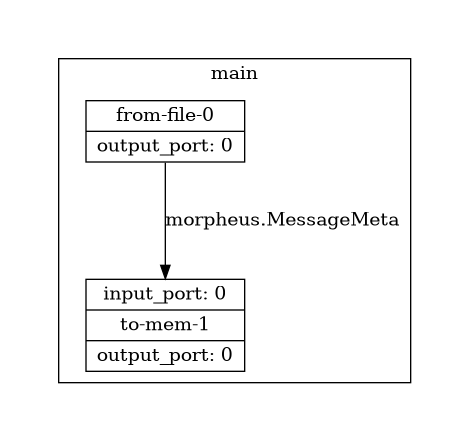

In [10]:
Image(filename=viz_file)

In [11]:
reset_logging()
configure_logging(log_level=logging.DEBUG)

====Starting Pipeline====
====Building Segment: main====
Added source: <from-file-0; FileSourceStage(filename=data/simple_user_log.jsonlines, iterative=False, file_type=FileTypes.Auto, repeat=1, filter_null=True, filter_null_columns=None, parser_kwargs=None)>
  └─> morpheus.MessageMeta
Added stage: <to-mem-1; InMemorySinkStage()>
  └─ morpheus.MessageMeta -> morpheus.MessageMeta
====Pipeline Started====
====Building Segment Complete!====
====Pipeline Complete====


In [12]:
await pipeline.run_async()

In [13]:
messages = in_mem_sink.get_messages()
messages[0].get_data()

,timestamp,user,ip_address,request_time,status,error_message
0,2025-02-01T10:15:30Z,user123,192.168.1.10,200.45,success,<NA>
1,2025-02-01T10:17:00Z,user123,192.168.1.20,150.55,failure,Invalid credentials
2,2025-02-01T10:18:10Z,user456,10.0.0.5,180.60,success,<NA>
3,2025-02-01T10:19:25Z,user789,192.168.1.30,215.25,failure,Timeout
4,2025-02-01T10:20:00Z,user456,10.0.0.6,120.10,success,<NA>
5,2025-02-01T10:22:30Z,user123,192.168.1.40,175.35,failure,Access denied
6,2025-02-01T10:23:45Z,user321,192.168.1.50,205.50,success,<NA>
7,2025-02-01T10:25:05Z,user864,192.168.1.60,190.15,failure,Invalid session
8,2025-02-01T10:26:20Z,user123,192.168.1.70,210.80,success,<NA>
9,2025-02-01T10:27:40Z,user456,10.0.0.7,160.95,failure,Account locked
